<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/BCNN%201K/Model4_BCNN_ECG_Version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian Modeling with Pyro and PyTorch

GOOD ATTEMPT

Jennifer's version of Dr. Colebank's BCNN model baseline with Fatemeh's parameter values (prior scale = 2.0, adaptive pooling)with batch normalization and relu for each layer.



## Adding Files to Google *Drive*

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pwd

/content


In [4]:
!ls

drive  sample_data


In [5]:
%cd /content/drive/MyDrive/REU ECG Analysis

/content/drive/MyDrive/REU ECG Analysis


In [6]:
ls

ECG_metrics_1K.npy  ECG_waveforms_1K.npy  EchoNext_EchoData_5K.csv


In [7]:
# Uncomment this line if Pyro is not installed.
%pip install pyro-ppl torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 16.4 MB/s eta 0:00:00


In [8]:
import torch

# Check if CUDA (NVIDIA GPU) is available
print(torch.cuda.is_available())  # Must output: True

# Get the name of your GPU
print(torch.cuda.get_device_name(0))


True
Tesla T4


In [9]:
# Automatically select GPU if available, otherwise fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## 1. Imports and Reproducibility

We will use:

- `torch` for tensors, neural network layers, and optimization.
- `pyro` for probabilistic models and variational inference.
- `torchvision` for MNIST.
- `matplotlib` for visualization.

In [10]:
import math
import os
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.nn import PyroModule, PyroSample
from pyro.optim import Adam

try:
    from torchvision import datasets, transforms
    TORCHVISION_AVAILABLE = True
except Exception as e:
    TORCHVISION_AVAILABLE = False
    print("torchvision could not be imported:", e)

In [11]:
def set_seed(seed=0):
    """Set random seeds for reproducible examples."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
pyro.set_rng_seed(42)
pyro.clear_param_store()

# Use a GPU if one is available. Otherwise use the CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
print("Using device:", device)

Using device: cuda


# Part I: Bayesian Linear Regression

## 2. Mathematical Model

Suppose we observe pairs $(x_i, y_i)$. A standard linear regression model assumes

$$
y_i = wx_i + b + \epsilon_i,
$$

where $w$ is the slope, $b$ is the intercept, and $\epsilon_i$ is random noise.

In a **Bayesian** model, we place prior distributions on unknown quantities. For example:

$$
w \sim \mathcal{N}(0, 10),
$$

$$
b \sim \mathcal{N}(0, 10),
$$

$$
\sigma \sim \text{LogNormal}(0, 1),
$$

$$
y_i \mid x_i, w, b, \sigma \sim \mathcal{N}(wx_i + b, \sigma).
$$

After observing data, the posterior distribution tells us which values of \(w\), \(b\), and \($\sigma$\) are plausible.

# Part II: Bayesian CNN for MNIST

## 9. CNN Classification Setup

MNIST contains grayscale images of handwritten digits. Each image has shape \(1 \times 28 \times 28\), and the label is one of 10 classes.

A conventional CNN learns fixed convolutional filters. A Bayesian CNN places probability distributions over the filters and dense-layer weights.

In this example, we use a very small CNN:

1. Bayesian convolution layer from 1 channel to 4 channels.
2. ReLU and max pooling.
3. Bayesian convolution layer from 4 channels to 8 channels.
4. ReLU and max pooling.
5. Bayesian fully connected hidden layer.
6. Bayesian output layer for 10 digit classes.

Because the CNN weights are random variables, prediction is performed by sampling multiple networks from the posterior and averaging their predicted probabilities.

## 10. Load MNIST

The next cell downloads MNIST using `torchvision`. To keep the Bayesian CNN example fast, we use small subsets by default.

You can increase `train_subset_size`, `test_subset_size`, `num_epochs`, or `max_batches_per_epoch` if you want a more serious experiment.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

import sympy
import sympy.core          # force submodule onto the namespace
import sympy.core.symbol
import torch               # now import torch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import importlib
sympy.core = importlib.import_module("sympy.core")
sympy.core.symbol = importlib.import_module("sympy.core.symbol")
print(hasattr(sympy, 'core'))

# Optional imports for MNIST.
# If torchvision is not installed, the synthetic time-series example will still run.

try:
    import torchvision
    import torchvision.transforms as transforms
    TORCHVISION_AVAILABLE = True
except ImportError:
    TORCHVISION_AVAILABLE = False

np.random.seed(42)
torch.manual_seed(42) #42

# Use a GPU if available. Otherwise, use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


True
Using device: cuda


In [13]:
from re import X
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks

ECG_data_1K = np.load('ECG_waveforms_1K.npy')
# ECG_summary_1K = np.load('ECG_metrics_1K.npy')
Echo_5K = pd.read_csv('EchoNext_EchoData_5K.csv')

labels = Echo_5K['shd_moderate_or_greater_flag']


#initial definitions
negative = labels==0
positive = labels==1
y_ts = torch.tensor(labels[:1000], device=device)
X = torch.tensor(ECG_data_1K[:1000])
X_ts = torch.swapaxes(X, 1, 2).to(device)
print(X_ts.shape)
print(y_ts.shape)


torch.Size([1000, 12, 2500])
torch.Size([1000])


In [26]:
#train & test
X_ts_tensor = torch.tensor(X_ts, dtype=torch.float32)
y_ts_tensor = torch.tensor(y_ts, dtype=torch.long)


#needs to be cuda, ind = 0
print(X_ts_tensor.device)
print(y_ts_tensor.device)

X_mean = X_ts_tensor.mean(dim=(0, 2), keepdim=True)
X_std = X_ts_tensor.std(dim=(0, 2), keepdim=True).clamp_min(1e-6)

X_ts_standard = (X_ts_tensor - X_mean) / X_std

ts_dataset = TensorDataset(X_ts_standard, y_ts_tensor)

train_size = int(0.8 * len(ts_dataset))
test_size = len(ts_dataset) - train_size

ts_train_dataset, ts_test_dataset = random_split(
    ts_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

ts_train_loader = DataLoader(ts_train_dataset, batch_size=32, shuffle=True) #change batch size
batch = next(iter(ts_train_loader))


print(batch[0].shape)

ts_test_loader = DataLoader(ts_test_dataset, batch_size=128, shuffle=False)

print("Time-series training samples:", len(ts_train_dataset))
print("Time-series test samples:", len(ts_test_dataset))


cuda:0
cuda:0


/tmp/ipykernel_6774/4159374481.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_ts_tensor = torch.tensor(X_ts, dtype=torch.float32)
/tmp/ipykernel_6774/4159374481.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_ts_tensor = torch.tensor(y_ts, dtype=torch.long)


AttributeError: 'DataLoader' object has no attribute 'is_cuda'

In [15]:
print(np.shape(X_std))

torch.Size([1, 12, 1])


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

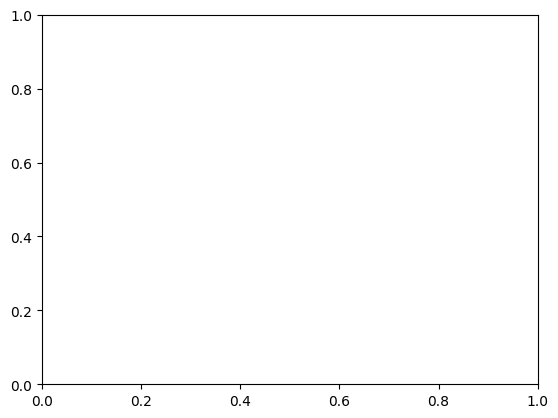

In [16]:
plt.figure()
plt.plot(ts_train_dataset[1][0][2,0:100])
plt.plot(ts_test_dataset[1][0][2,0:100])
plt.show()

## 12. Define a Bayesian CNN with PyroModule and PyroSample

`PyroModule` allows a PyTorch module to contain random parameters.

`PyroSample` replaces a deterministic parameter, such as a weight tensor, with a prior distribution. During inference, Pyro learns an approximate posterior over these random tensors.

The model below uses:

- Normal priors for convolution and dense weights.
- Categorical likelihood for class labels.
- Logits returned by the CNN.

The final likelihood is

$$
y_i \mid x_i, \theta \sim \text{Categorical}(\text{logits}=f_\theta(x_i)),
$$

where $\theta$ represents all Bayesian weights and biases.

In [43]:
class BayesianSmallCNN(PyroModule):
    def __init__(
        self,
        prior_scale=0.10,
        num_filters_1=8,
        num_filters_2=12,
        kernel_size_1=5,
        kernel_size_2=5,
        input_channels=12,
        input_length=2500,
        hidden_dim=32,
        num_classes=2,
        prior_mean = 0.0,
        avg_pool = True,
        device = "cpu"  #default cpu
    ):
        super().__init__()

        # This preserves sequence length when kernel_size is odd.
        # For kernel_size=5, padding=2.
        # For kernel_size=11, padding=5.
        padding_1 = kernel_size_1 // 2
        padding_2 = kernel_size_2 // 2


        self.input_channels = input_channels
        self.input_length = input_length
        self.num_filters_1 = num_filters_1
        self.num_filters_2 = num_filters_2
        self.kernel_size_1 = kernel_size_1
        self.kernel_size_2 = kernel_size_2
        self.prior_scale = prior_scale
        self.avg_pool = avg_pool
        self.conv1 = PyroModule[nn.Conv1d](
            input_channels,
            num_filters_1,
            kernel_size=kernel_size_1,
            padding=padding_1,
        )
        self.conv1.weight = PyroSample(
            dist.Normal(torch.tensor(prior_mean, device=device), torch.tensor(prior_scale, device=device))
            .expand([num_filters_1, input_channels, kernel_size_1])
            .to_event(3)
        )
        self.conv1.bias = PyroSample(
            dist.Normal(torch.tensor(prior_mean, device=device), torch.tensor(prior_scale, device=device))
            .expand([num_filters_1])
            .to_event(1)
        )

        self.conv2 = PyroModule[nn.Conv1d](
            num_filters_1,
            num_filters_2,
            kernel_size=kernel_size_2,
            padding=padding_2,
        )
        self.conv2.weight = PyroSample(
            dist.Normal(torch.tensor(prior_mean, device=device), torch.tensor(prior_scale, device=device))
            .expand([num_filters_2, num_filters_1, kernel_size_2])
            .to_event(3)
        )
        self.conv2.bias = PyroSample(
            dist.Normal(torch.tensor(prior_mean, device=device), torch.tensor(prior_scale, device=device))
            .expand([num_filters_2])
            .to_event(1)
        )

        self.bn1 = nn.BatchNorm1d(num_filters_1)
        self.bn2 = nn.BatchNorm1d(num_filters_2)

        # Two max-pooling layers with kernel_size=2 reduce length by factor of 4.
        pooled_length = input_length // 4 #ignore
        if avg_pool:
            self.flattened_dim = num_filters_2 #change if needed
        else:
           self.flattened_dim = num_filters * pooled_length #check this

        self.fc1 = PyroModule[nn.Linear](self.flattened_dim, hidden_dim)
        self.fc1.weight = PyroSample(
             dist.Normal(torch.tensor(prior_mean, device=device), torch.tensor(prior_scale, device=device))
            .expand([hidden_dim, self.flattened_dim])
            .to_event(2)
        )
        self.fc1.bias = PyroSample(
            dist.Normal(torch.tensor(prior_mean, device=device), torch.tensor(prior_scale, device=device))
            .expand([hidden_dim])
            .to_event(1)
        )

        self.fc2 = PyroModule[nn.Linear](hidden_dim, num_classes)
        self.fc2.weight = PyroSample(
            dist.Normal(torch.tensor(prior_mean, device=device), torch.tensor(prior_scale, device=device))
            .expand([num_classes, hidden_dim])
            .to_event(2)
        )
        self.fc2.bias = PyroSample(
            dist.Normal(torch.tensor(prior_mean, device=device), torch.tensor(prior_scale, device=device))
            .expand([num_classes])
            .to_event(1)
        )

    def forward(self, x, y=None, dataset_size=None):
        batch_size = x.shape[0]
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = F.max_pool1d(x, kernel_size=2)

        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = F.max_pool1d(x, kernel_size=2)

        if self.avg_pool:
            x = F.adaptive_avg_pool1d(x,1)
        x = torch.flatten(x, start_dim=1)

        x = torch.relu(self.fc1(x))
        logits = self.fc2(x)

        if y is not None:
            y = y.to(x.device)

            if dataset_size is not None:
                scale = dataset_size / batch_size
            else:
                scale = 1.0

            with pyro.plate("data", batch_size):
                with pyro.poutine.scale(scale=scale):
                    pyro.sample("obs", dist.Categorical(logits=logits), obs=y)

        return logits

## 13. Create the Guide and SVI Object

We again use `AutoDiagonalNormal`. For a Bayesian CNN, this means Pyro creates a diagonal Normal variational posterior over all Bayesian weights and biases.

This is not the only possible guide, but it is a clear starting point for teaching and experimentation.

In [44]:
pyro.clear_param_store()
set_seed(42)

bcnn =  BayesianSmallCNN(
    prior_scale=2.0,
    num_filters_1=8,
    num_filters_2=12,
    kernel_size_1=9,
    kernel_size_2=15, #this model does better than MODEL2_BayesianCNN for bigger kernel sizes (?)
    prior_mean=0.0,
    avg_pool=True,
    device=device
)

bcnn.to(device)

bcnn_guide = AutoDiagonalNormal(bcnn)
bcnn_guide = bcnn_guide.to(device)

bcnn_optimizer = Adam({"lr": 1e-2,"betas": (0.9, 0.999)})
bcnn_svi = SVI(
    model=bcnn,
    guide=bcnn_guide,
    optim=bcnn_optimizer,
    loss=Trace_ELBO(),
)

#should be true for gpu
print(next(bcnn.parameters()).is_cuda)

True


## 14. Training and Evaluation Utilities

The training loop is similar to ordinary PyTorch, except the optimization step is `svi.step(images, labels)` rather than `loss.backward()` followed by `optimizer.step()`.

For prediction, we sample several networks from the approximate posterior and average their softmax probabilities.

In [45]:
def debug_pyro_devices(model, guide):
    print("\n=== PYRO DEVICE DIAGNOSTIC ===")



    # 2. Check Model Weights
    model_devices = {p.device for p in model.parameters()}
    print(f"Model Weights Device(s): {list(model_devices) if model_devices else 'No parameters'}")

    # 3. Check Guide Weights
    guide_devices = {p.device for p in guide.parameters()}
    print(f"Guide Weights Device(s): {list(guide_devices) if guide_devices else 'No parameters'}")

    # 4. Check Pyro's Internal Param Store
    print("Pyro Param Store Devices:")
    param_store = pyro.get_param_store()
    if not param_store:
        print("  [Empty - SVI has not run a step yet]")
    for name, tensor in param_store.items():
        print(f"  - {name}: {tensor.device}")
    print("==============================\n")


In [46]:
def train_one_epoch_svi(svi, data_loader, device, dataset_size, max_batches=None):

    #debug_pyro_devices(svi.model, svi.guide)
    total_loss = 0.0
    total_examples = 0

    for batch_idx, (x, y) in enumerate(data_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)


        loss = svi.step(x, y, dataset_size)
        total_loss += loss
        total_examples += x.shape[0]

    return total_loss / max(1, batch_idx) / dataset_size

@torch.no_grad()
def predict_proba_bayesian(model, guide, x, num_samples=250):
    """Average class probabilities over posterior samples of the network."""
    predictive = Predictive(
        model,
        guide=guide,
        num_samples=num_samples,
        return_sites=("_RETURN",),
    )
    out = predictive(x, None)

    # Shape is usually [num_samples, batch_size, num_classes].
    logits_samples = out["_RETURN"]
    probs_samples = torch.softmax(logits_samples, dim=-1)
    mean_probs = probs_samples.mean(dim=0)
    return mean_probs


@torch.no_grad()
def evaluate_bayesian_classifier(model, guide, data_loader, device, num_samples=2500, max_batches=None):
    """Evaluate posterior-averaged classification accuracy."""
    correct = 0
    total = 0

    for batch_idx, (x, y) in enumerate(data_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)
        mean_probs = predict_proba_bayesian(model, guide, x, num_samples=num_samples)
        preds = mean_probs.argmax(dim=-1)
        correct += (preds == y).sum().item()
        total += y.numel()

    return correct / max(1, total)

## 15. Train the Bayesian CNN

This cell uses conservative defaults so it can run on a laptop. For better performance, try increasing:

- `train_subset_size`
- `num_epochs`
- `max_batches_per_epoch`
- `num_prediction_samples`

Fully Bayesian CNNs are much slower than deterministic CNNs because each prediction can require many posterior samples.


=== PYRO DEVICE DIAGNOSTIC ===
Model Weights Device(s): [device(type='cuda', index=0)]
Guide Weights Device(s): [device(type='cuda', index=0)]
Pyro Param Store Devices:
  - bn1$$$weight: cuda:0
  - bn1$$$bias: cuda:0
  - bn2$$$weight: cuda:0
  - bn2$$$bias: cuda:0
  - AutoDiagonalNormal.loc: cuda:0
  - AutoDiagonalNormal.scale: cuda:0

Epoch  1/100 | avg negative ELBO per example = 0.78 | approx train accuracy = 0.700approx test accuracy = 0.710

=== PYRO DEVICE DIAGNOSTIC ===
Model Weights Device(s): [device(type='cuda', index=0)]
Guide Weights Device(s): [device(type='cuda', index=0)]
Pyro Param Store Devices:
  - bn1$$$weight: cuda:0
  - bn1$$$bias: cuda:0
  - bn2$$$weight: cuda:0
  - bn2$$$bias: cuda:0
  - AutoDiagonalNormal.loc: cuda:0
  - AutoDiagonalNormal.scale: cuda:0

Epoch  2/100 | avg negative ELBO per example = 0.79 | approx train accuracy = 0.725approx test accuracy = 0.745

=== PYRO DEVICE DIAGNOSTIC ===
Model Weights Device(s): [device(type='cuda', index=0)]
Guide Weig

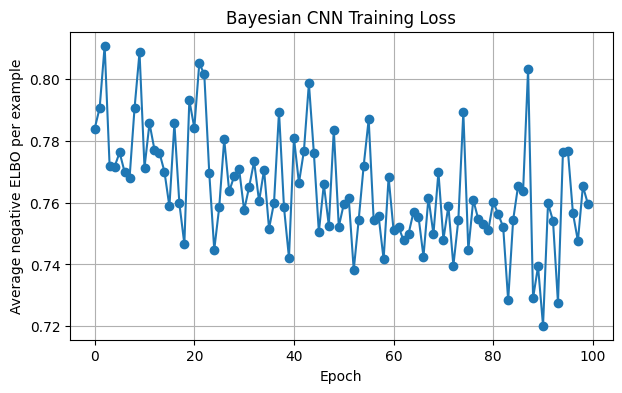

In [50]:
num_epochs = 100
max_batches_per_epoch = None
num_prediction_samples = 25

bcnn_losses = []

for epoch in range(num_epochs):
    avg_loss = train_one_epoch_svi(
    bcnn_svi,
    ts_train_loader,
    device,
    dataset_size = train_size,
    max_batches=max_batches_per_epoch,
)
    bcnn_losses.append(avg_loss)

    train_acc = evaluate_bayesian_classifier(
        bcnn,
        bcnn_guide,
        ts_train_loader,
        device,
        num_samples=num_prediction_samples,
        max_batches=5,
    )

    test_acc = evaluate_bayesian_classifier(
        bcnn,
        bcnn_guide,
        ts_test_loader,
        device,
        num_samples=num_prediction_samples,
        max_batches=4,
    )

    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"avg negative ELBO per example = {avg_loss:.2f} | "
        f"approx train accuracy = {train_acc:.3f}"
        f"approx test accuracy = {test_acc:.3f}"
    )

plt.figure(figsize=(7, 4))
plt.plot(bcnn_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average negative ELBO per example")
plt.title("Bayesian CNN Training Loss")
plt.grid(True)
plt.show()

Posterior mean shape: torch.Size([10294])
Posterior std shape: torch.Size([10294])


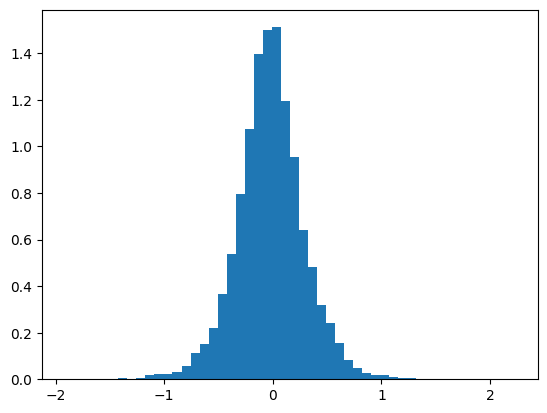

In [ ]:
posterior = bcnn_guide.get_posterior()

posterior_mean = posterior.mean.detach().cpu()
posterior_std = posterior.stddev.detach().cpu()

plt.figure()
plt.hist(x=posterior_mean.flatten().numpy(), bins=50, density=True)

print("Posterior mean shape:", posterior_mean.shape)
print("Posterior std shape:", posterior_std.shape)

In [ ]:
train_acc = evaluate_bayesian_classifier(
    bcnn,
    bcnn_guide,
    ts_train_loader,
    device,
    num_samples=100
)

test_acc = evaluate_bayesian_classifier(
    bcnn,
    bcnn_guide,
    ts_test_loader,
    device,
    num_samples=100
)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

@torch.no_grad()
def get_predictions(model, guide, data_loader, device, num_samples=250):
    all_preds = []
    all_labels = []

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)

        mean_probs = predict_proba_bayesian(
            model, guide, x, num_samples=num_samples
        )
        preds = mean_probs.argmax(dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)


y_true, y_pred = get_predictions(
    bcnn,
    bcnn_guide,
    ts_test_loader,
    device,
    num_samples=100
)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[71 29]
 [22 78]]
              precision    recall  f1-score   support

           0       0.76      0.71      0.74       100
           1       0.73      0.78      0.75       100

    accuracy                           0.74       200
   macro avg       0.75      0.74      0.74       200
weighted avg       0.75      0.74      0.74       200



## 16. Visualize Bayesian CNN Predictions

The predicted class is obtained by averaging softmax probabilities over posterior samples.

The maximum averaged probability gives a simple uncertainty summary:

- High value: the posterior ensemble mostly agrees.
- Low value: the posterior ensemble is less confident.

In [ ]:
def plot_ecg_prediction_grid(
    ecgs,
    y_true,
    y_pred,
    probs,
    indices=None,
    lead=0,
    n_cols=3,
    class_names=None,
    sampling_rate=None,
):
    """
    Plot one lead from multiple ECGs with true/predicted labels.

    Args:
        lead: which ECG lead to plot, zero-indexed.
              lead=0 means first lead.
    """
    if class_names is None:
        class_names = {0: "Class 0", 1: "Class 1"}

    if indices is None:
        indices = np.arange(min(9, len(ecgs)))

    indices = np.array(indices)
    n_plots = len(indices)
    n_rows = int(np.ceil(n_plots / n_cols))

    n_time = ecgs.shape[-1]

    if sampling_rate is not None:
        t = np.arange(n_time) / sampling_rate
        x_label = "Time (seconds)"
    else:
        t = np.arange(n_time)
        x_label = "Time index"

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 3 * n_rows),
        sharex=True,
    )

    axes = np.array(axes).reshape(-1)

    for ax_idx, sample_idx in enumerate(indices):
        ax = axes[ax_idx]

        ecg_lead = ecgs[sample_idx, lead]
        true_label = int(y_true[sample_idx])
        pred_label = int(y_pred[sample_idx])
        pred_prob = probs[sample_idx, pred_label]
        positive_prob = probs[sample_idx, 1]

        true_name = class_names[true_label]
        pred_name = class_names[pred_label]

        ax.plot(t, ecg_lead)
        ax.grid(True, alpha=0.3)

        correctness = "Correct" if true_label == pred_label else "Incorrect"

        ax.set_title(
            f"Idx {sample_idx} | {correctness}\n"
            f"True: {true_name}\n"
            f"Pred: {pred_name}, P={pred_prob:.2f}, P1={positive_prob:.2f}",
            fontsize=10,
        )

        ax.set_xlabel(x_label)
        ax.set_ylabel(f"Lead {lead + 1}")

    for ax_idx in range(n_plots, len(axes)):
        axes[ax_idx].axis("off")

    plt.tight_layout()
    plt.show()


import numpy as np
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def get_predictions_with_ecgs(
    model,
    guide,
    data_loader,
    device,
    num_samples=100,
):
    """
    Collect ECGs, true labels, predicted labels, and posterior predictive probabilities.

    Returns:
        ecgs: shape [N, 12, 2500]
        y_true: shape [N]
        y_pred: shape [N]
        probs: shape [N, 2]
    """
    all_ecgs = []
    all_labels = []
    all_preds = []
    all_probs = []

    model.eval()

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)

        mean_probs = predict_proba_bayesian(
            model,
            guide,
            x,
            num_samples=num_samples,
        )

        preds = mean_probs.argmax(dim=-1)

        all_ecgs.append(x.detach().cpu())
        all_labels.append(y.detach().cpu())
        all_preds.append(preds.detach().cpu())
        all_probs.append(mean_probs.detach().cpu())

    ecgs = torch.cat(all_ecgs, dim=0).numpy()
    y_true = torch.cat(all_labels, dim=0).numpy()
    y_pred = torch.cat(all_preds, dim=0).numpy()
    probs = torch.cat(all_probs, dim=0).numpy()

    return ecgs, y_true, y_pred, probs

## 17. Class Probability Bar Plot for One Image

A Bayesian classifier gives a distribution over model weights. After averaging over posterior samples, we get posterior-averaged class probabilities.

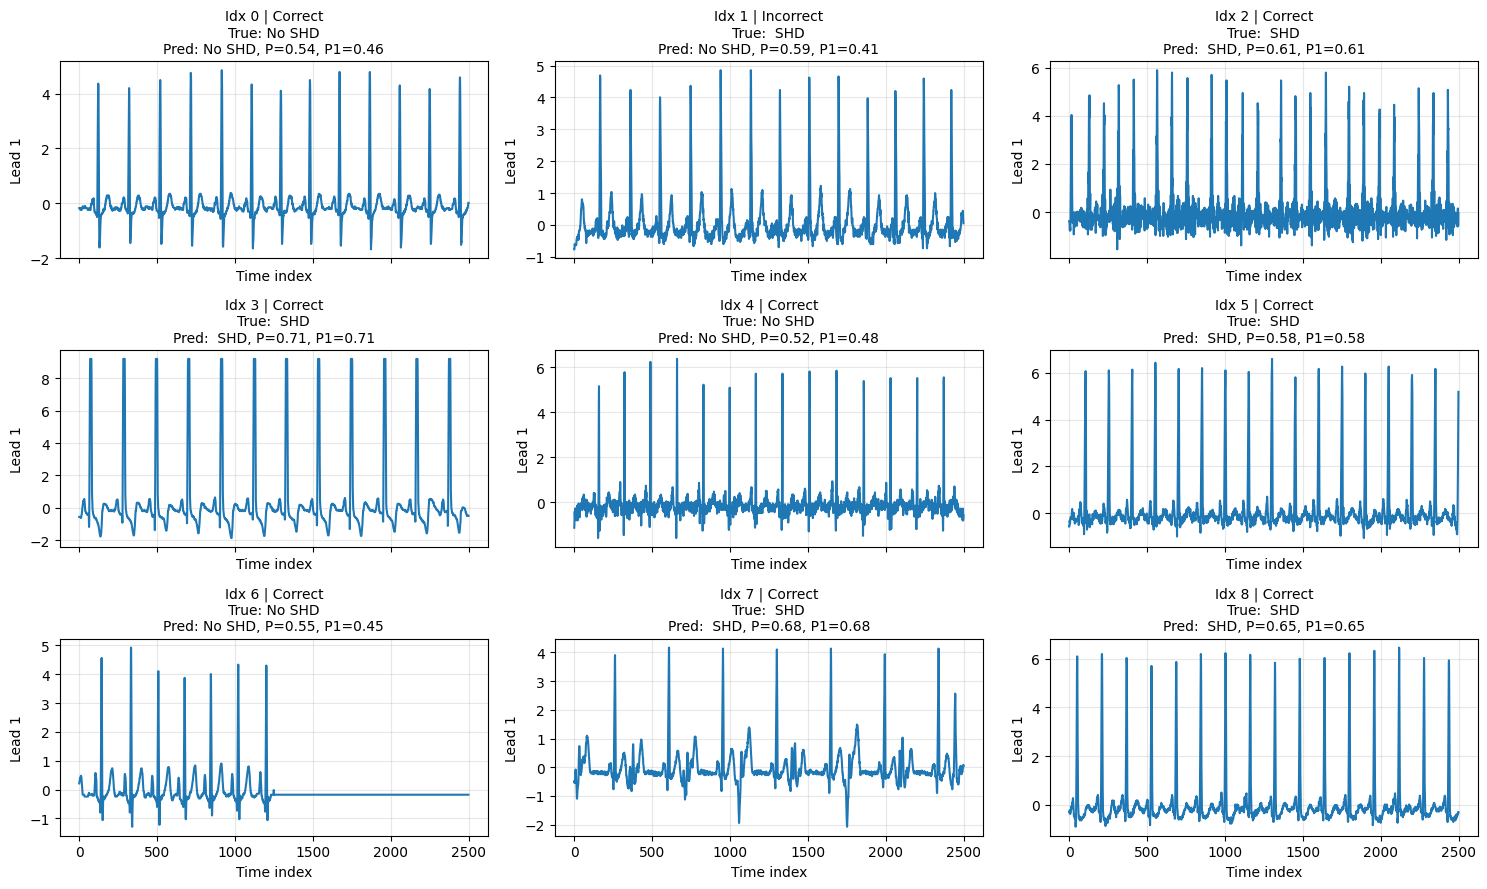

In [ ]:
class_names = {
    0: "No SHD",
    1: " SHD",
}


ecgs, y_true, y_pred, probs = get_predictions_with_ecgs(
    model=bcnn,
    guide=bcnn_guide,
    data_loader=ts_test_loader,
    device=device,
    num_samples=10,
)

plot_ecg_prediction_grid(
  ecgs,
  y_true,
  y_pred,
  probs,
  indices=np.arange(9),
  lead=0,
  n_cols=3,
  class_names=class_names,
  sampling_rate=None,
)